<a href="https://colab.research.google.com/github/Shambhuraje1919/Machine_Learning_Paractice/blob/main/Social_Media_Addiction_Analysis%2C_Visualization%2C_and_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [84]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("harpartapsingh13/social-media-addiction-and-mental-wellbeing-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'social-media-addiction-and-mental-wellbeing-dataset' dataset.
Path to dataset files: /kaggle/input/social-media-addiction-and-mental-wellbeing-dataset


In [85]:
import os
import pandas as pd
import numpy as np

In [86]:
os.listdir(path)

['social_media_addiction_mental_wellbeing.csv']

In [87]:
df = pd.read_csv(os.path.join(path,'social_media_addiction_mental_wellbeing.csv'))

In [88]:
df.head()

,User_ID,Age,Gender,Occupation,Relationship_Status,Primary_Platform,Daily_Usage_Hours,Platforms_Used_Count,Posts_Per_Week,Late_Night_Usage,...,Loneliness_Score,Self_Esteem_Score,Sleep_Quality_Score,Sleep_Hours,Productivity_Loss_Score,Offline_Relationship_Quality,Physical_Activity_Hrs_Week,Screen_Free_Time_Hrs,Mental_Wellbeing_Score,Addiction_Level
0,USR00001,30,Male,Working Professional,In a Relationship,YouTube,2.9,4,3,No,...,1.7,6.5,8.5,5.3,3.7,3.8,5.8,3.1,7.3,Low
1,USR00002,19,Male,Student,Married,Instagram,4.8,1,0,NaN,...,7.0,7.5,7.8,5.5,4.0,1.8,0.9,3.3,4.1,Severe
2,USR00003,40,Male,Student,In a Relationship,YouTube,NaN,4,5,No,...,5.6,5.3,6.3,NaN,5.8,2.8,0.0,1.5,5.6,High
3,USR00004,37,Female,Student,Married,Facebook,7.7,2,3,Yes,...,5.6,1.4,3.9,6.1,5.5,3.6,1.0,3.9,4.3,Severe
4,USR00005,18,Non-binary,Student,In a Relationship,TikTok,4.6,3,0,No,...,4.0,NaN,5.7,5.0,3.8,3.2,0.6,1.0,6.6,Moderate


In [89]:
df = df.drop('User_ID',axis=1)

In [90]:
df.head()

,Age,Gender,Occupation,Relationship_Status,Primary_Platform,Daily_Usage_Hours,Platforms_Used_Count,Posts_Per_Week,Late_Night_Usage,First_Check_Morning,...,Loneliness_Score,Self_Esteem_Score,Sleep_Quality_Score,Sleep_Hours,Productivity_Loss_Score,Offline_Relationship_Quality,Physical_Activity_Hrs_Week,Screen_Free_Time_Hrs,Mental_Wellbeing_Score,Addiction_Level
0,30,Male,Working Professional,In a Relationship,YouTube,2.9,4,3,No,Within 5 min,...,1.7,6.5,8.5,5.3,3.7,3.8,5.8,3.1,7.3,Low
1,19,Male,Student,Married,Instagram,4.8,1,0,NaN,Within 5 min,...,7.0,7.5,7.8,5.5,4.0,1.8,0.9,3.3,4.1,Severe
2,40,Male,Student,In a Relationship,YouTube,NaN,4,5,No,Within 5 min,...,5.6,5.3,6.3,NaN,5.8,2.8,0.0,1.5,5.6,High
3,37,Female,Student,Married,Facebook,7.7,2,3,Yes,Within 5 min,...,5.6,1.4,3.9,6.1,5.5,3.6,1.0,3.9,4.3,Severe
4,18,Non-binary,Student,In a Relationship,TikTok,4.6,3,0,No,5-30 min,...,4.0,NaN,5.7,5.0,3.8,3.2,0.6,1.0,6.6,Moderate


In [91]:
df.isnull().mean()*100

,0
Age,0.000000
Gender,3.533333
Occupation,3.000000
Relationship_Status,3.400000
Primary_Platform,3.533333
Daily_Usage_Hours,3.733333
Platforms_Used_Count,0.000000
Posts_Per_Week,0.000000
Late_Night_Usage,3.333333
First_Check_Morning,0.000000


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 29 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Age                           1500 non-null   int64  
 1   Gender                        1447 non-null   object 
 2   Occupation                    1455 non-null   object 
 3   Relationship_Status           1449 non-null   object 
 4   Primary_Platform              1447 non-null   object 
 5   Daily_Usage_Hours             1444 non-null   float64
 6   Platforms_Used_Count          1500 non-null   int64  
 7   Posts_Per_Week                1500 non-null   int64  
 8   Late_Night_Usage              1450 non-null   object 
 9   First_Check_Morning           1500 non-null   object 
 10  Notifications_Per_Day         1500 non-null   int64  
 11  FOMO_Score                    1445 non-null   float64
 12  Social_Comparison_Score       1449 non-null   float64
 13  Val

In [93]:
import seaborn as sns

In [94]:
print(df['Sleep_Hours'].min())
df['Sleep_Hours'].max()

3.0


10.0

<Axes: xlabel='Sleep_Hours'>

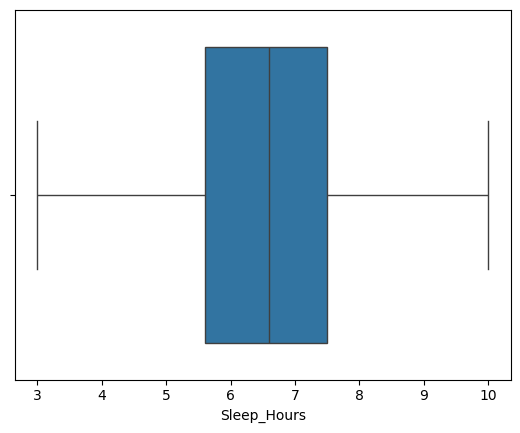

In [95]:
sns.boxplot(data = df ,x='Sleep_Hours')

<Axes: xlabel='Loneliness_Score'>

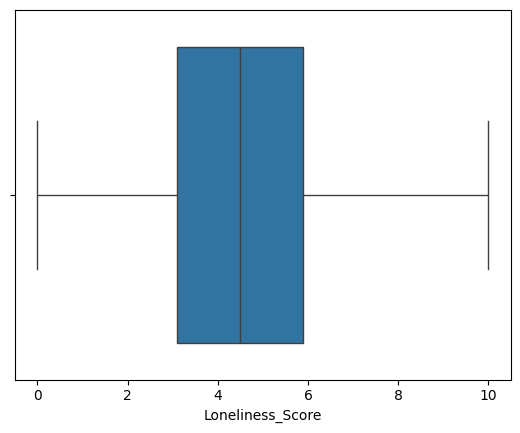

In [96]:
sns.boxplot(data = df , x = 'Loneliness_Score')

In [97]:
import plotly.express as pl

In [98]:
fig = pl.scatter_3d(
    df,
    x = 'Loneliness_Score',
    y = 'Sleep_Quality_Score',
    z = 'Anxiety_Score',
    color='Addiction_Level',
    animation_frame='Relationship_Status',
    #facet_col='',
    title="Addiction Level Based on Loneliness, Sleep, and Anxiety"
)
fig.show()

In [99]:
fig = pl.histogram(
    df,
    x='Relationship_Status',
    color='Addiction_Level',
    barmode='group',
    title='Addiction Level by Relationship Status'
)

fig.show()

In [100]:
print("Single Are less Addicted horrey !!!!!")

Single Are less Addicted horrey !!!!!


In [101]:


cross = df.groupby(
    ['Relationship_Status', 'Addiction_Level']
).size().reset_index(name='Count')

fig = pl.density_heatmap(
    cross,
    x='Relationship_Status',
    y='Addiction_Level',
    z='Count',
    text_auto=True,
    title='Relationship Status vs Addiction Level'
)

fig.show()

In [102]:
import pandas as pd

pd.crosstab(
    df["Relationship_Status"],
    df["Addiction_Level"],
    normalize="index"
) * 100

Addiction_Level,High,Low,Moderate,Severe
Relationship_Status,,,,
In a Relationship,23.667377,26.226013,30.703625,19.402985
Married,21.348315,30.337079,33.146067,15.168539
Single,25.480769,27.884615,27.243590,19.391026


In [103]:
from scipy.stats import chi2_contingency
import pandas as pd

table = pd.crosstab(df["Relationship_Status"], df["Addiction_Level"])

chi2, p, dof, expected = chi2_contingency(table)

print(f"Chi-square: {chi2:.2f}")
print(f"p-value: {p:.4f}")

Chi-square: 8.31
p-value: 0.2165


In [104]:
print('Observation Although Single participants show a slightly higher percentage of High addiction (25.48%), the Chi-Square test (χ² = 8.31, p = 0.2165) indicates that this difference is not statistically significant. Therefore, Relationship Status does not appear to have a significant impact on Addiction Level in this dataset.')

Observation Although Single participants show a slightly higher percentage of High addiction (25.48%), the Chi-Square test (χ² = 8.31, p = 0.2165) indicates that this difference is not statistically significant. Therefore, Relationship Status does not appear to have a significant impact on Addiction Level in this dataset.


In [105]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

,0
Offline_Relationship_Quality,4.666667
Self_Esteem_Score,4.600000
Sleep_Quality_Score,4.533333
Sleep_Hours,4.133333
Screen_Free_Time_Hrs,4.000000
Validation_Seeking_Score,3.866667
Daily_Usage_Hours,3.733333
Loneliness_Score,3.666667
Depression_Score,3.666667
FOMO_Score,3.666667


In [106]:
from sklearn.impute import SimpleImputer

num_cols = [
    "Offline_Relationship_Quality",
    "Self_Esteem_Score",
    "Sleep_Quality_Score",
    "Sleep_Hours",
    "Screen_Free_Time_Hrs",
    "Validation_Seeking_Score",
    "Daily_Usage_Hours",
    "Loneliness_Score",
    "Depression_Score",
    "FOMO_Score",
    "Productivity_Loss_Score",
    "Physical_Activity_Hrs_Week",
    "Social_Comparison_Score",
    "Anxiety_Score"
]

imputer = SimpleImputer(strategy="median")
df[num_cols] = imputer.fit_transform(df[num_cols])

In [107]:
cat_cols = [
    "Gender",
    "Primary_Platform",
    "Relationship_Status",
    "Occupation",
    "Failed_To_Cut_Back",
    "Tried_To_Cut_Back"
]

imputer = SimpleImputer(strategy="most_frequent")
df[cat_cols] = imputer.fit_transform(df[cat_cols])

In [108]:
df[num_cols].skew().sort_values()

,0
FOMO_Score,-0.116142
Self_Esteem_Score,-0.107735
Sleep_Quality_Score,-0.048349
Anxiety_Score,-0.042674
Sleep_Hours,-0.026799
Validation_Seeking_Score,0.006727
Social_Comparison_Score,0.007745
Offline_Relationship_Quality,0.009614
Loneliness_Score,0.032945
Productivity_Loss_Score,0.045453


In [109]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

X = df.drop("Addiction_Level", axis=1)
y = df["Addiction_Level"]

num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns

X[num_cols] = X[num_cols].fillna(X[num_cols].mean())

for col in cat_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

X = pd.get_dummies(X, drop_first=True)

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, pred_lr))
print("Random Forest Accuracy:", accuracy_score(y_test, pred_rf))

print("\nLogistic Regression Report\n")
print(classification_report(y_test, pred_lr, target_names=le.classes_))

print("\nRandom Forest Report\n")
print(classification_report(y_test, pred_rf, target_names=le.classes_))

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nTop 15 Important Features\n")
print(importance.head(15))

fig = pl.bar(
    importance.head(15),
    x="Importance",
    y="Feature",
    orientation="h",
    title="Top 15 Important Features"
)
fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



Logistic Regression Accuracy: 0.8
Random Forest Accuracy: 0.75

Logistic Regression Report

              precision    recall  f1-score   support

        High       0.78      0.71      0.74        72
         Low       0.85      0.86      0.85        84
    Moderate       0.75      0.79      0.77        90
      Severe       0.84      0.85      0.84        54

    accuracy                           0.80       300
   macro avg       0.80      0.80      0.80       300
weighted avg       0.80      0.80      0.80       300


Random Forest Report

              precision    recall  f1-score   support

        High       0.66      0.62      0.64        72
         Low       0.84      0.87      0.85        84
    Moderate       0.68      0.74      0.71        90
      Severe       0.85      0.74      0.79        54

    accuracy                           0.75       300
   macro avg       0.76      0.74      0.75       300
weighted avg       0.75      0.75      0.75       300


Top 15 Importa